In [21]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import matplotlib.pyplot as plt


In [13]:
DATASET_PATH = "../celeba_hq_256"

In [14]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5,0.5,0.5],
        [0.5,0.5,0.5]
    )
])

In [15]:
class CelebADataset(Dataset):
    
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform

        self.images = [
            file for file in os.listdir(folder_path)
            if file.endswith((".jpg",".jpeg",".png"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.folder_path,
            self.images[idx]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [16]:
dataset = CelebADataset(
    DATASET_PATH,
    transform=transform
)

print("Dataset Size:", len(dataset))

Dataset Size: 30000


In [17]:
dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("DataLoader Ready")

DataLoader Ready


In [23]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([128, 3, 64, 64])


In [24]:
image = batch[0]

print(image.shape)

torch.Size([3, 64, 64])


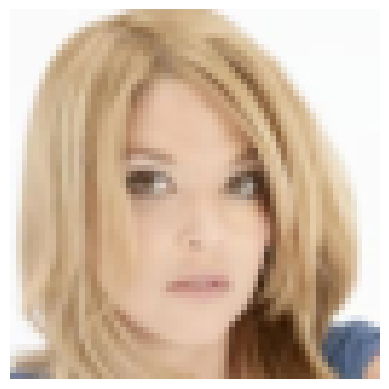

In [25]:
image = image.permute(1, 2, 0)

image = (image + 1) / 2

plt.imshow(image)
plt.axis("off")
plt.show()